In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from link_prediction.config import (
    RESULTS_DIR,
    SUMMARY_RESULTS_DIR,
    load_experiment_config,
    load_methods_config,
    load_networks_config,
)
from link_prediction.datasets import (
    compute_sha256,
)
from link_prediction.statistical_analysis import (
    load_benchmark_fold_metrics,
    write_statistical_csv,
)

In [2]:
benchmark_name = "standard"

experiment_config = (
    load_experiment_config()
)

methods_config = (
    load_methods_config()
)

networks_config = (
    load_networks_config()
)

expected_network_ids = list(
    networks_config[
        "benchmarks"
    ][
        benchmark_name
    ]
)

expected_method_ids = [
    method_id
    for method_id, method
    in methods_config[
        "methods"
    ].items()
    if method.get(
        "enabled",
        True,
    )
]

expected_fold_count = int(
    experiment_config[
        "experiment"
    ][
        "n_folds"
    ]
)

report_directory = (
    RESULTS_DIR
    / "reports"
    / benchmark_name
)

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

report_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

fold_metrics = (
    load_benchmark_fold_metrics(
        benchmark_name=
            benchmark_name,
    )
)

dataset_manifest = pd.read_csv(
    SUMMARY_RESULTS_DIR
    / (
        f"{benchmark_name}_"
        "dataset_manifest.csv"
    )
)

In [3]:
expected_row_count = (
    len(
        expected_network_ids
    )
    * expected_fold_count
    * len(
        expected_method_ids
    )
)

network_fold_sizes = (
    fold_metrics
    .groupby(
        [
            "network_id",
            "fold",
        ]
    )[
        "method_id"
    ]
    .nunique()
)

network_method_fold_sizes = (
    fold_metrics
    .groupby(
        [
            "network_id",
            "method_id",
        ]
    )[
        "fold"
    ]
    .nunique()
)

source_hashes_valid = (
    dataset_manifest[
        "source_sha256"
    ]
    .astype(str)
    .str.fullmatch(
        r"[0-9a-f]{64}"
    )
    .all()
)

integrity_checks = pd.DataFrame(
    [
        {
            "check":
                "network_count",
            "expected":
                len(
                    expected_network_ids
                ),
            "observed":
                fold_metrics[
                    "network_id"
                ].nunique(),
        },
        {
            "check":
                "method_count",
            "expected":
                len(
                    expected_method_ids
                ),
            "observed":
                fold_metrics[
                    "method_id"
                ].nunique(),
        },
        {
            "check":
                "fold_count",
            "expected":
                expected_fold_count,
            "observed":
                fold_metrics[
                    "fold"
                ].nunique(),
        },
        {
            "check":
                "fold_metric_row_count",
            "expected":
                expected_row_count,
            "observed":
                len(
                    fold_metrics
                ),
        },
        {
            "check":
                "methods_per_network_fold",
            "expected":
                len(
                    expected_method_ids
                ),
            "observed":
                int(
                    network_fold_sizes.min()
                ),
        },
        {
            "check":
                "folds_per_network_method",
            "expected":
                expected_fold_count,
            "observed":
                int(
                    network_method_fold_sizes.min()
                ),
        },
        {
            "check":
                "dataset_manifest_count",
            "expected":
                len(
                    expected_network_ids
                ),
            "observed":
                len(
                    dataset_manifest
                ),
        },
        {
            "check":
                "dataset_source_hashes",
            "expected":
                True,
            "observed":
                bool(
                    source_hashes_valid
                ),
        },
    ]
)

integrity_checks[
    "passed"
] = (
    integrity_checks[
        "expected"
    ]
    == integrity_checks[
        "observed"
    ]
)

if not integrity_checks[
    "passed"
].all():
    failed_checks = (
        integrity_checks[
            ~integrity_checks[
                "passed"
            ]
        ][
            "check"
        ].tolist()
    )

    raise RuntimeError(
        "Final result integrity checks "
        "failed: "
        f"{failed_checks}"
    )

write_statistical_csv(
    integrity_checks,
    report_directory
    / "result_integrity_checks.csv",
)

integrity_checks

,check,expected,observed,passed
0,network_count,8,8,True
1,method_count,27,27,True
2,fold_count,5,5,True
3,fold_metric_row_count,1080,1080,True
4,methods_per_network_fold,27,27,True
5,folds_per_network_method,5,5,True
6,dataset_manifest_count,8,8,True
7,dataset_source_hashes,True,True,True


In [4]:
metric_columns = [
    "average_precision",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "ndcg",
]

network_method_summary = (
    fold_metrics
    .groupby(
        [
            "benchmark",
            "network_id",
            "network",
            "domain",
            "family",
            "analysis_family",
            "method_id",
            "method",
        ],
        sort=False,
    )[
        metric_columns
    ]
    .agg(
        [
            "mean",
            "std",
        ]
    )
    .reset_index()
)

network_method_summary.columns = [
    "_".join(
        part
        for part in column
        if part
    )
    if isinstance(
        column,
        tuple,
    )
    else column
    for column
    in network_method_summary.columns
]

overall_rows = []

for (
    method_values,
    group,
) in network_method_summary.groupby(
    [
        "family",
        "analysis_family",
        "method_id",
        "method",
    ],
    sort=False,
):
    (
        family,
        analysis_family,
        method_id,
        method,
    ) = method_values

    row = {
        "family":
            family,
        "analysis_family":
            analysis_family,
        "method_id":
            method_id,
        "method":
            method,
        "network_count":
            group[
                "network_id"
            ].nunique(),
    }

    for metric in metric_columns:
        values = group[
            f"{metric}_mean"
        ]

        row[
            f"{metric}_mean"
        ] = float(
            values.mean()
        )

        row[
            f"{metric}_sd_across_networks"
        ] = float(
            values.std()
        )

    overall_rows.append(
        row
    )

overall_method_summary = (
    pd.DataFrame(
        overall_rows
    )
)

overall_method_summary[
    "average_precision_rank"
] = (
    overall_method_summary[
        "average_precision_mean"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

overall_method_summary = (
    overall_method_summary
    .sort_values(
        [
            "average_precision_rank",
            "method",
        ]
    )
    .reset_index(
        drop=True
    )
)

In [5]:
network_family_summary = (
    network_method_summary
    .groupby(
        [
            "benchmark",
            "network_id",
            "network",
            "domain",
            "analysis_family",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        method_count=(
            "method_id",
            "nunique",
        ),
        average_precision_mean=(
            "average_precision_mean",
            "mean",
        ),
        roc_auc_mean=(
            "roc_auc_mean",
            "mean",
        ),
        precision_mean=(
            "precision_mean",
            "mean",
        ),
        recall_mean=(
            "recall_mean",
            "mean",
        ),
        f1_mean=(
            "f1_mean",
            "mean",
        ),
        ndcg_mean=(
            "ndcg_mean",
            "mean",
        ),
    )
)

family_summary = (
    network_family_summary
    .groupby(
        [
            "analysis_family",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        network_count=(
            "network_id",
            "nunique",
        ),
        method_count=(
            "method_count",
            "max",
        ),
        average_precision_mean=(
            "average_precision_mean",
            "mean",
        ),
        average_precision_sd_across_networks=(
            "average_precision_mean",
            "std",
        ),
        roc_auc_mean=(
            "roc_auc_mean",
            "mean",
        ),
        roc_auc_sd_across_networks=(
            "roc_auc_mean",
            "std",
        ),
    )
)

best_method_by_network = (
    network_method_summary
    .sort_values(
        [
            "network_id",
            "average_precision_mean",
            "method_id",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .groupby(
        "network_id",
        as_index=False,
        sort=False,
    )
    .head(1)
    .reset_index(
        drop=True
    )
)

result_tables = {
    "network_method_summary":
        network_method_summary,
    "overall_method_summary":
        overall_method_summary,
    "network_family_summary":
        network_family_summary,
    "family_summary":
        family_summary,
    "best_method_by_network":
        best_method_by_network,
}

for table_name, table in (
    result_tables.items()
):
    write_statistical_csv(
        table,
        report_directory
        / f"{table_name}.csv",
    )

In [6]:
overall_method_summary[
    [
        "average_precision_rank",
        "method",
        "analysis_family",
        "network_count",
        "average_precision_mean",
        "average_precision_sd_across_networks",
        "roc_auc_mean",
        "roc_auc_sd_across_networks",
    ]
]

,average_precision_rank,method,analysis_family,network_count,average_precision_mean,average_precision_sd_across_networks,roc_auc_mean,roc_auc_sd_across_networks
0,1,SRW-l3,quasi_local_walk,8,0.922042,0.083499,0.922299,0.083608
1,2,FL-l3,quasi_local_path,8,0.918040,0.081777,0.919219,0.081959
2,3,LPI-beta-0.001,quasi_local_path,8,0.918001,0.081756,0.919203,0.081949
3,4,ORA-CNI-beta-0.001,quasi_local_path,8,0.912332,0.079684,0.914384,0.080160
4,5,RA-CNI,enhanced_local,8,0.908619,0.085577,0.910584,0.086274
5,6,PFP-l3,quasi_local_walk,8,0.908563,0.079384,0.913858,0.080223
6,7,LRW-l3,quasi_local_walk,8,0.884737,0.118542,0.886278,0.117043
7,8,IA1,enhanced_local,8,0.880987,0.122998,0.881078,0.123326
8,9,RA,standard_local,8,0.880878,0.123104,0.881149,0.123429
9,10,LNB-RA,local_bayesian,8,0.880859,0.123015,0.881051,0.123363


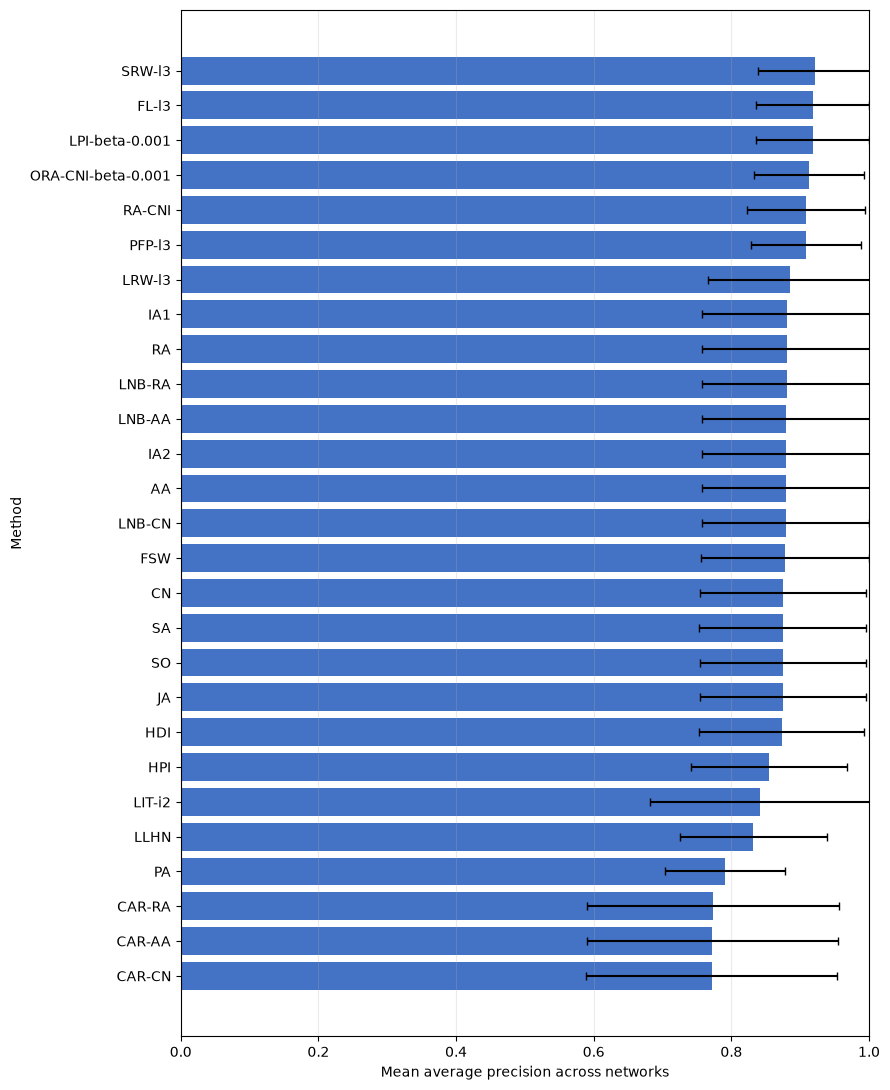

In [7]:
plot_table = (
    overall_method_summary
    .sort_values(
        [
            "average_precision_mean",
            "method",
        ]
    )
)

figure, axis = plt.subplots(
    figsize=(
        9,
        11,
    )
)

axis.barh(
    plot_table[
        "method"
    ],
    plot_table[
        "average_precision_mean"
    ],
    xerr=plot_table[
        "average_precision_sd_across_networks"
    ],
    color="#4472C4",
    capsize=3,
)

axis.set_xlabel(
    "Mean average precision across networks"
)

axis.set_ylabel(
    "Method"
)

axis.set_xlim(
    0.0,
    1.0,
)

axis.grid(
    axis="x",
    alpha=0.25,
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "overall_method_average_precision.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "overall_method_average_precision.pdf",
    bbox_inches="tight",
)

plt.show()

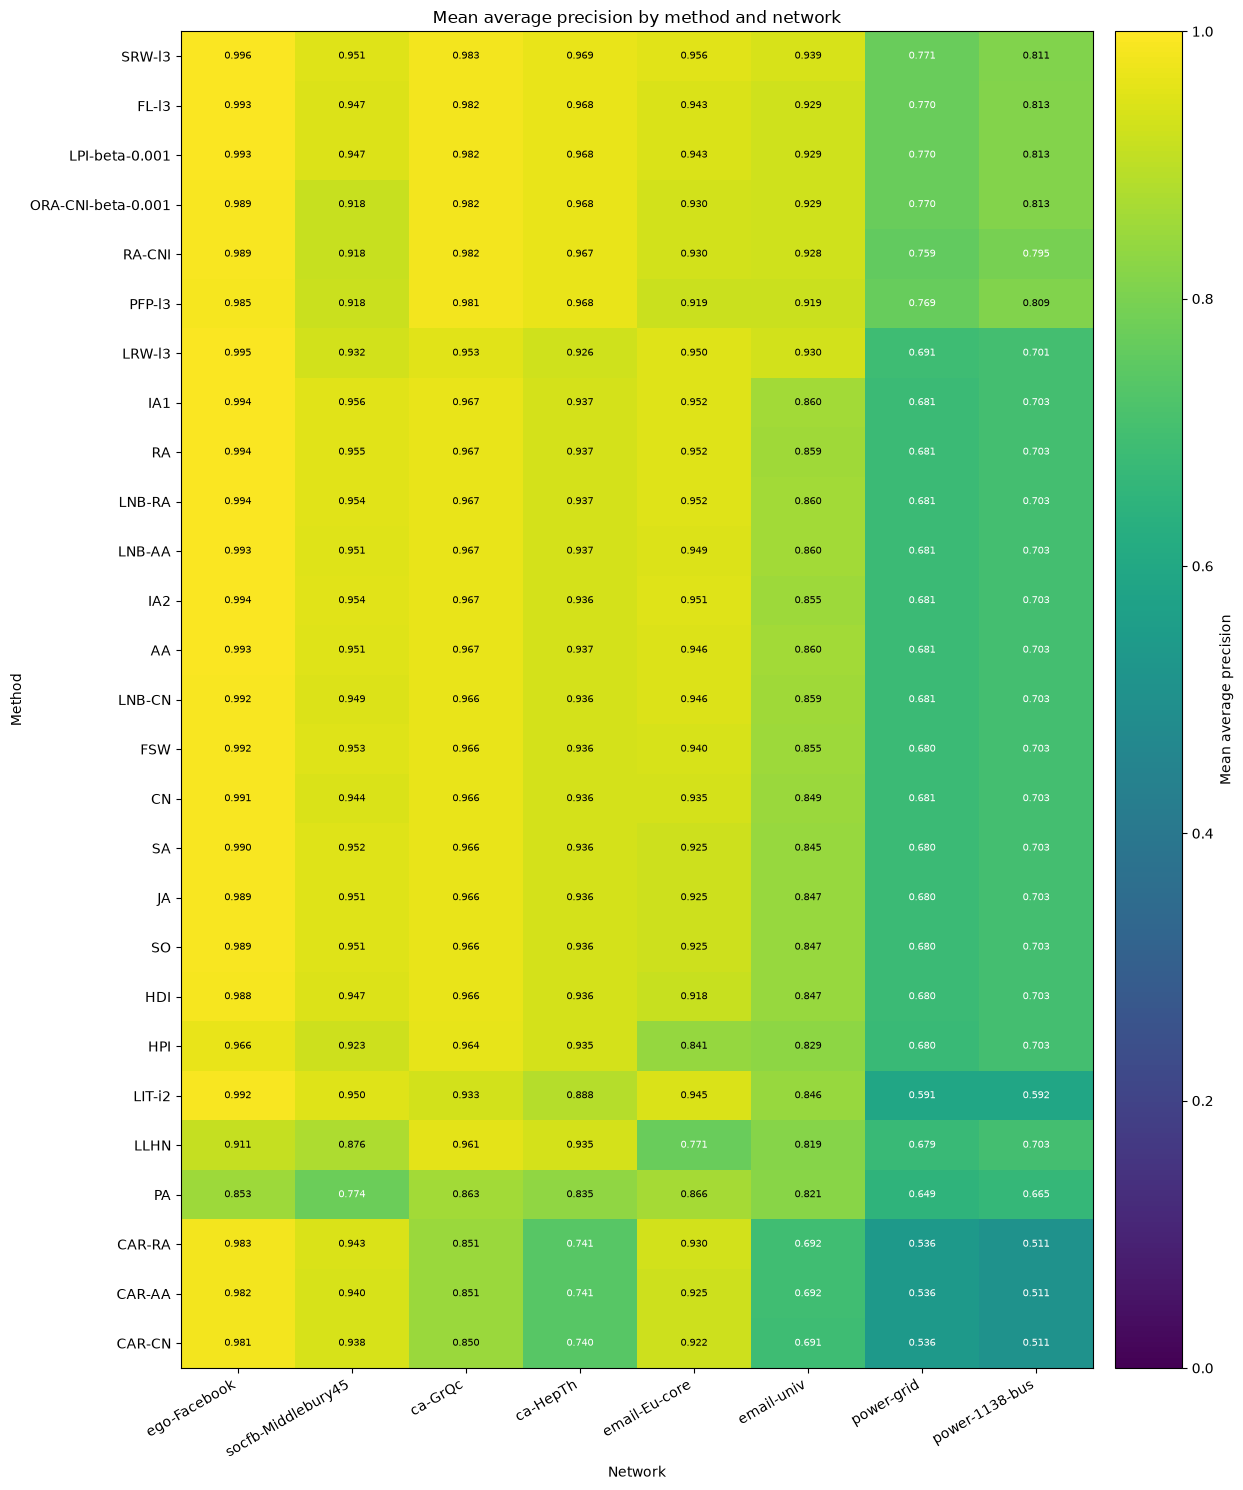

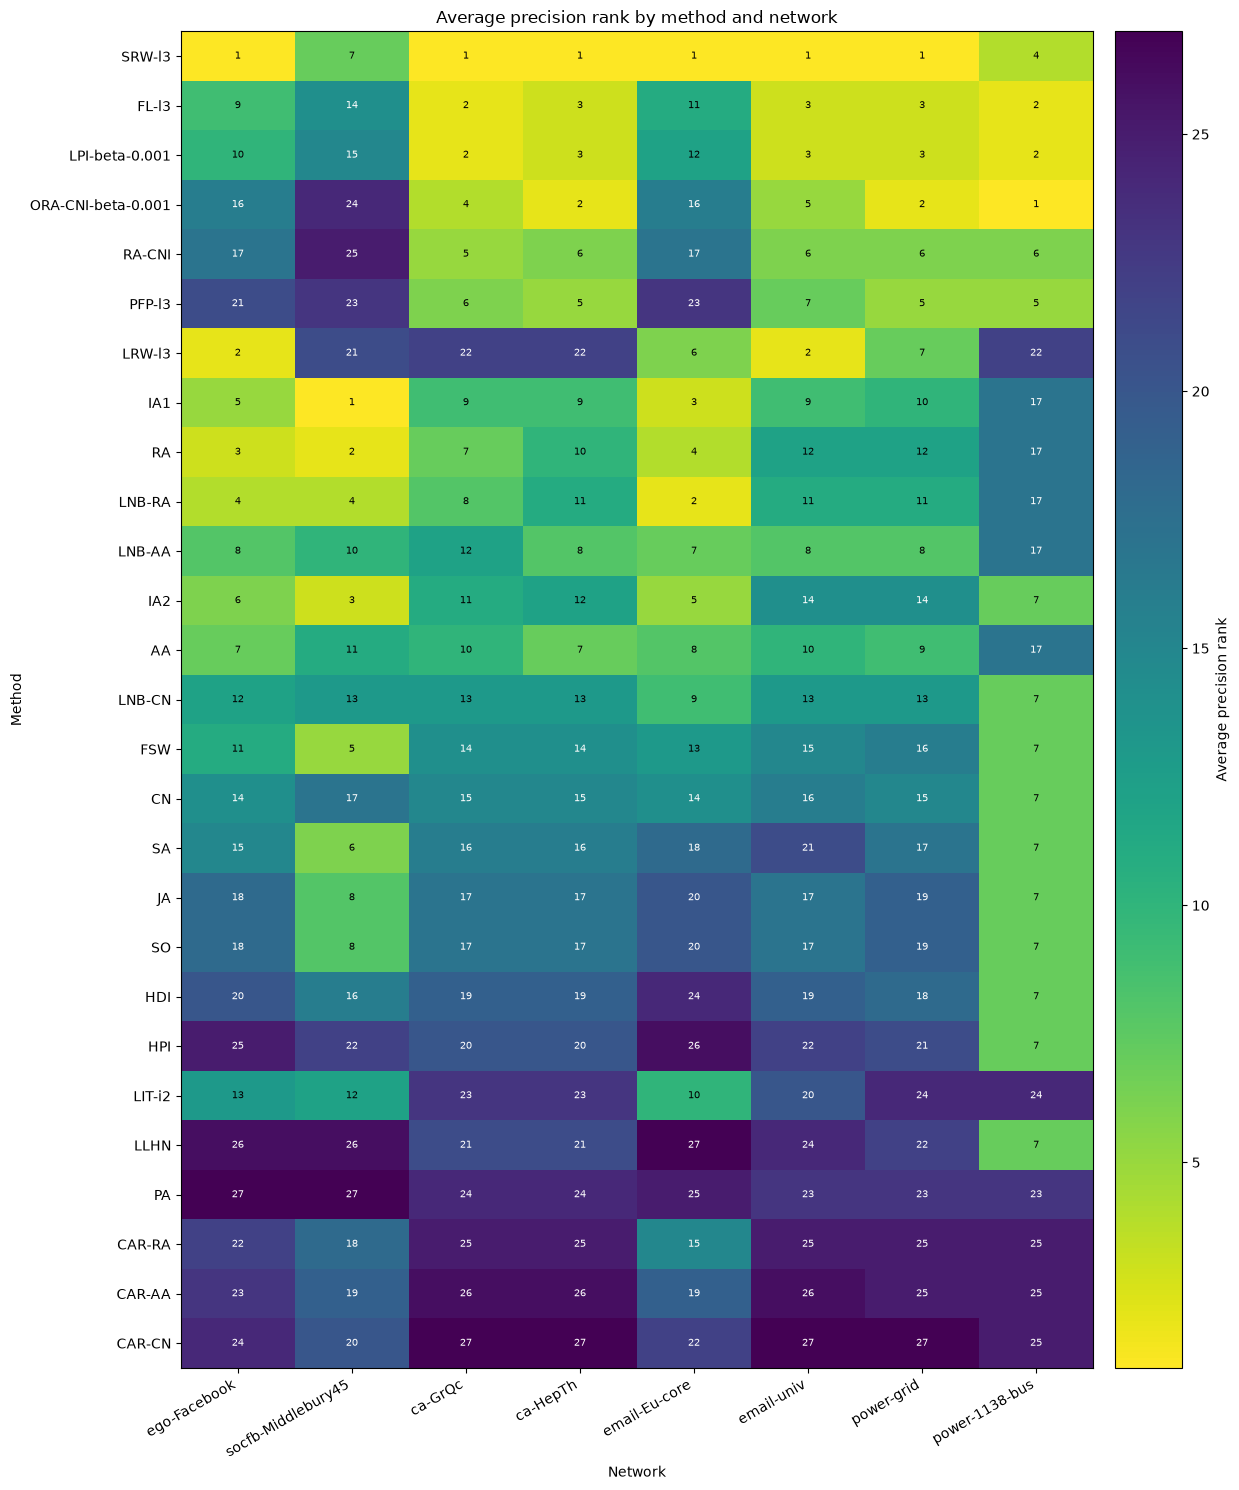

In [8]:
method_order = (
    overall_method_summary
    .sort_values(
        [
            "average_precision_rank",
            "method",
        ]
    )[
        "method"
    ]
    .tolist()
)

network_order = [
    networks_config[
        "networks"
    ][
        network_id
    ][
        "name"
    ]
    for network_id in expected_network_ids
]

average_precision_matrix = (
    network_method_summary
    .pivot(
        index="method",
        columns="network",
        values="average_precision_mean",
    )
    .reindex(
        index=method_order,
        columns=network_order,
    )
)

figure, axis = plt.subplots(
    figsize=(
        13,
        15,
    )
)

image = axis.imshow(
    average_precision_matrix.to_numpy(),
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axis.set_xticks(
    range(
        len(
            average_precision_matrix.columns
        )
    )
)

axis.set_xticklabels(
    average_precision_matrix.columns,
    rotation=30,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            average_precision_matrix.index
        )
    )
)

axis.set_yticklabels(
    average_precision_matrix.index
)

for row_index in range(
    len(
        average_precision_matrix.index
    )
):
    for column_index in range(
        len(
            average_precision_matrix.columns
        )
    ):
        value = average_precision_matrix.iloc[
            row_index,
            column_index,
        ]

        axis.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=7,
            color=(
                "black"
                if value >= 0.80
                else "white"
            ),
        )

axis.set_xlabel(
    "Network"
)

axis.set_ylabel(
    "Method"
)

axis.set_title(
    "Mean average precision by method and network"
)

colorbar = figure.colorbar(
    image,
    ax=axis,
    pad=0.02,
)

colorbar.set_label(
    "Mean average precision"
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "network_method_average_precision_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "network_method_average_precision_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

network_rank_table = (
    network_method_summary.copy()
)

network_rank_table[
    "average_precision_rank"
] = (
    network_rank_table
    .groupby(
        "network_id"
    )[
        "average_precision_mean"
    ]
    .rank(
        method="min",
        ascending=False,
    )
)

rank_matrix = (
    network_rank_table
    .pivot(
        index="method",
        columns="network",
        values="average_precision_rank",
    )
    .reindex(
        index=method_order,
        columns=network_order,
    )
)

figure, axis = plt.subplots(
    figsize=(
        13,
        15,
    )
)

image = axis.imshow(
    rank_matrix.to_numpy(),
    aspect="auto",
    cmap="viridis_r",
    vmin=1,
    vmax=len(method_order),
)

axis.set_xticks(
    range(
        len(
            rank_matrix.columns
        )
    )
)

axis.set_xticklabels(
    rank_matrix.columns,
    rotation=30,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            rank_matrix.index
        )
    )
)

axis.set_yticklabels(
    rank_matrix.index
)

for row_index in range(
    len(
        rank_matrix.index
    )
):
    for column_index in range(
        len(
            rank_matrix.columns
        )
    ):
        value = rank_matrix.iloc[
            row_index,
            column_index,
        ]

        axis.text(
            column_index,
            row_index,
            f"{int(value)}",
            ha="center",
            va="center",
            fontsize=7,
            color=(
                "black"
                if value <= 13
                else "white"
            ),
        )

axis.set_xlabel(
    "Network"
)

axis.set_ylabel(
    "Method"
)

axis.set_title(
    "Average precision rank by method and network"
)

colorbar = figure.colorbar(
    image,
    ax=axis,
    pad=0.02,
)

colorbar.set_label(
    "Average precision rank"
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "network_method_average_precision_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "network_method_average_precision_rank_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

In [9]:
artifact_paths = [
    report_directory
    / "result_integrity_checks.csv",
    *[
        report_directory
        / f"{table_name}.csv"
        for table_name
        in result_tables
    ],
    figure_directory
    / "overall_method_average_precision.png",
    figure_directory
    / "overall_method_average_precision.pdf",
    figure_directory
    / "network_method_average_precision_heatmap.png",
    figure_directory
    / "network_method_average_precision_heatmap.pdf",
    figure_directory
    / "network_method_average_precision_rank_heatmap.png",
    figure_directory
    / "network_method_average_precision_rank_heatmap.pdf",
]

artifact_rows = []

for path in artifact_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Expected artifact not found: {path}"
        )

    artifact_rows.append(
        {
            "artifact":
                path.name,
            "path":
                str(
                    path.relative_to(
                        RESULTS_DIR
                    )
                ),
            "size_bytes":
                path.stat().st_size,
            "sha256":
                compute_sha256(
                    path
                ),
        }
    )

artifact_manifest = (
    pd.DataFrame(
        artifact_rows
    )
)

write_statistical_csv(
    artifact_manifest,
    report_directory
    / "artifact_manifest.csv",
)

artifact_manifest

,artifact,path,size_bytes,sha256
0,result_integrity_checks.csv,reports/standard/result_integrity_checks.csv,274,778346347a7442c8907c22118303c291238eb88ddb12b9...
1,network_method_summary.csv,reports/standard/network_method_summary.csv,71895,e8e574bd56079cc6cf68d76f0ef34aeae70e2944bcc948...
2,overall_method_summary.csv,reports/standard/overall_method_summary.csv,7841,a2e8df0ee443017e01cec7f0a8c87affe42d359892dfd7...
3,network_family_summary.csv,reports/standard/network_family_summary.csv,7355,b8072f7d2fdea5b15a55a5d1b030b045401de2a699b5a4...
4,family_summary.csv,reports/standard/family_summary.csv,625,749b31c80087f99a673096298005f0ae9970129467d5dd...
5,best_method_by_network.csv,reports/standard/best_method_by_network.csv,2915,4aefa50c31817ba29e83791d4dd349038b469e4aa4ba3e...
6,overall_method_average_precision.png,figures/standard/overall_method_average_precis...,158669,4516735d5976d5b78519ecbe8fc72dc36e540678ff5d3b...
7,overall_method_average_precision.pdf,figures/standard/overall_method_average_precis...,19232,65327d4c9de14769bfdd0b2fb174ae52dab42e931e5c8b...
8,network_method_average_precision_heatmap.png,figures/standard/network_method_average_precis...,788139,514a8fd808871782c4cbd74764cb207f87c5d5800de966...
9,network_method_average_precision_heatmap.pdf,figures/standard/network_method_average_precis...,31935,852ca63091d11c8ce8966f60f01c2db4f9b2f696dcd54f...
